# UHC Transparency in Coverage — Exploratory Analysis
**Dataset:** `optum.uhc_tic.index_files` — 996 index files, reporting date 2026-06-01

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv('03_exploration_2026-06-03-2019.csv')
print(f'Shape: {df.shape}')

Shape: (8868, 18)


In [10]:
# Fix dtypes
df['PLAN_ID'] = df['PLAN_ID'].astype(str)

date_cols = ['REPORTING_DATE', 'LAST_UPDATED_ON']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

timestamp_cols = ['PROCESSED_AT', 'LOADED_AT']
for col in timestamp_cols:
    df[col] = pd.to_datetime(df[col])

print(df.dtypes)

SOURCE_FILE                           object
REPORTING_DATE                datetime64[ns]
PROCESSED_AT                  datetime64[ns]
REPORTING_ENTITY_NAME                 object
REPORTING_ENTITY_TYPE                 object
LAST_UPDATED_ON               datetime64[ns]
VERSION                               object
PLAN_NAME                             object
PLAN_ID                               object
PLAN_ID_TYPE                          object
PLAN_MARKET_TYPE                      object
PLAN_SPONSOR_NAME                     object
ISSUER_NAME                           object
IN_NETWORK_DESCRIPTION                object
IN_NETWORK_LOCATION                   object
ALLOWED_AMOUNT_DESCRIPTION            object
ALLOWED_AMOUNT_LOCATION               object
LOADED_AT                     datetime64[ns]
dtype: object


## 1. Basic Checks

In [6]:
# Row and column count
print(f'Total rows:    {len(df):,}')
print(f'Total columns: {len(df.columns)}')
print(f'Source files:  {df["SOURCE_FILE"].nunique():,}')

Total rows:    8,868
Total columns: 18
Source files:  996


In [8]:
# Null counts
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
print('Null counts:')
for col, count in nulls.items():
    pct = count / len(df) * 100
    print(f'  {col}: {count} ({pct:.1f}%)')

Null counts:
  PLAN_SPONSOR_NAME: 147 (1.7%)
  IN_NETWORK_DESCRIPTION: 10 (0.1%)
  IN_NETWORK_LOCATION: 10 (0.1%)
  ALLOWED_AMOUNT_DESCRIPTION: 8294 (93.5%)
  ALLOWED_AMOUNT_LOCATION: 8294 (93.5%)


In [11]:
# Data types
df.dtypes

SOURCE_FILE                           object
REPORTING_DATE                datetime64[ns]
PROCESSED_AT                  datetime64[ns]
REPORTING_ENTITY_NAME                 object
REPORTING_ENTITY_TYPE                 object
LAST_UPDATED_ON               datetime64[ns]
VERSION                               object
PLAN_NAME                             object
PLAN_ID                               object
PLAN_ID_TYPE                          object
PLAN_MARKET_TYPE                      object
PLAN_SPONSOR_NAME                     object
ISSUER_NAME                           object
IN_NETWORK_DESCRIPTION                object
IN_NETWORK_LOCATION                   object
ALLOWED_AMOUNT_DESCRIPTION            object
ALLOWED_AMOUNT_LOCATION               object
LOADED_AT                     datetime64[ns]
dtype: object

In [13]:
# Sample row
df.head()

,SOURCE_FILE,REPORTING_DATE,PROCESSED_AT,REPORTING_ENTITY_NAME,REPORTING_ENTITY_TYPE,LAST_UPDATED_ON,VERSION,PLAN_NAME,PLAN_ID,PLAN_ID_TYPE,PLAN_MARKET_TYPE,PLAN_SPONSOR_NAME,ISSUER_NAME,IN_NETWORK_DESCRIPTION,IN_NETWORK_LOCATION,ALLOWED_AMOUNT_DESCRIPTION,ALLOWED_AMOUNT_LOCATION,LOADED_AT
0,2026-06-01_ABLELIGHT-GROUP-BENEFIT-PLAN_index....,2026-06-01,2026-06-03 19:50:14.991,UMR-Inc,Third-Party Administrator,2026-07-01,2.0.0,ABLELIGHT-GROUP-BENEFIT-PLAN,390806446,EIN,group,ABLELIGHT-GROUP-BENEFIT-PLAN,ABLELIGHT-GROUP-BENEFIT-PLAN,in-network files,https://transparency-in-coverage.uhc.com/api/v...,allowed amount file,https://transparency-in-coverage.uhc.com/api/v...,2026-06-03 11:58:07.306
1,2026-06-01_ABLELIGHT-GROUP-BENEFIT-PLAN_index....,2026-06-01,2026-06-03 19:50:14.991,UMR-Inc,Third-Party Administrator,2026-07-01,2.0.0,ABLELIGHT-GROUP-BENEFIT-PLAN,390806446,EIN,group,ABLELIGHT-GROUP-BENEFIT-PLAN,ABLELIGHT-GROUP-BENEFIT-PLAN,in-network files,https://transparency-in-coverage.uhc.com/api/v...,allowed amount file,https://transparency-in-coverage.uhc.com/api/v...,2026-06-03 11:58:07.306
2,2026-06-01_ABLELIGHT-GROUP-BENEFIT-PLAN_index....,2026-06-01,2026-06-03 19:50:14.991,UMR-Inc,Third-Party Administrator,2026-07-01,2.0.0,ABLELIGHT-GROUP-BENEFIT-PLAN,390806446,EIN,group,ABLELIGHT-GROUP-BENEFIT-PLAN,ABLELIGHT-GROUP-BENEFIT-PLAN,in-network files,https://transparency-in-coverage.uhc.com/api/v...,allowed amount file,https://transparency-in-coverage.uhc.com/api/v...,2026-06-03 11:58:07.306
3,2026-06-01_ABLELIGHT-GROUP-BENEFIT-PLAN_index....,2026-06-01,2026-06-03 19:50:14.991,UMR-Inc,Third-Party Administrator,2026-07-01,2.0.0,ABLELIGHT-GROUP-BENEFIT-PLAN,390806446,EIN,group,ABLELIGHT-GROUP-BENEFIT-PLAN,ABLELIGHT-GROUP-BENEFIT-PLAN,in-network files,https://transparency-in-coverage.uhc.com/api/v...,allowed amount file,https://transparency-in-coverage.uhc.com/api/v...,2026-06-03 11:58:07.306
4,2026-06-01_ABLELIGHT-GROUP-BENEFIT-PLAN_index....,2026-06-01,2026-06-03 19:50:14.991,UMR-Inc,Third-Party Administrator,2026-07-01,2.0.0,ABLELIGHT-GROUP-BENEFIT-PLAN,390806446,EIN,group,ABLELIGHT-GROUP-BENEFIT-PLAN,ABLELIGHT-GROUP-BENEFIT-PLAN,in-network files,https://transparency-in-coverage.uhc.com/api/v...,allowed amount file,https://transparency-in-coverage.uhc.com/api/v...,2026-06-03 11:58:07.306


## 2. Key Insights

In [14]:
# --- Insight 1: Reporting entity distribution ---
entity_counts = df.groupby('REPORTING_ENTITY_NAME').agg(
    rows=('SOURCE_FILE', 'count'),
    unique_plans=('PLAN_ID', 'nunique'),
    source_files=('SOURCE_FILE', 'nunique')
).sort_values('rows', ascending=False)

print('Reporting entities:')
print(entity_counts.to_string())

Reporting entities:
                                    rows  unique_plans  source_files
REPORTING_ENTITY_NAME                                               
United-HealthCare-Services-Inc      7842           546           881
Oxford-Health-Plans-LLC              708            69            47
UMR-Inc                              284            54            53
Surest                                26            12            12
UnitedHealthcare-Insurance-Company     4             1             1
United-HealthCare-Services             3             1             1
HealthSCOPE-Benefits-Inc               1             1             1


Top 10 plan names:
PLAN_NAME
United-Healthcare-POS                    5428
United-Healthcare-EPO                    2413
UHC-EPO-Gated-INN-Only-ASO                312
Surest-ASO-POS-INN-OON                    232
ABLELIGHT-GROUP-BENEFIT-PLAN              174
Surest-ASO-EPO-INN-Only                    60
UHC-POS-Non-Gated-INN-OON-PCP-Req-ASO      37
POS-CHOICE-PLUS                            17
UHC-EPO-Non-Gated-INN-Only-PCP-Req         16
ASO-Non-Gated-PPO                          12


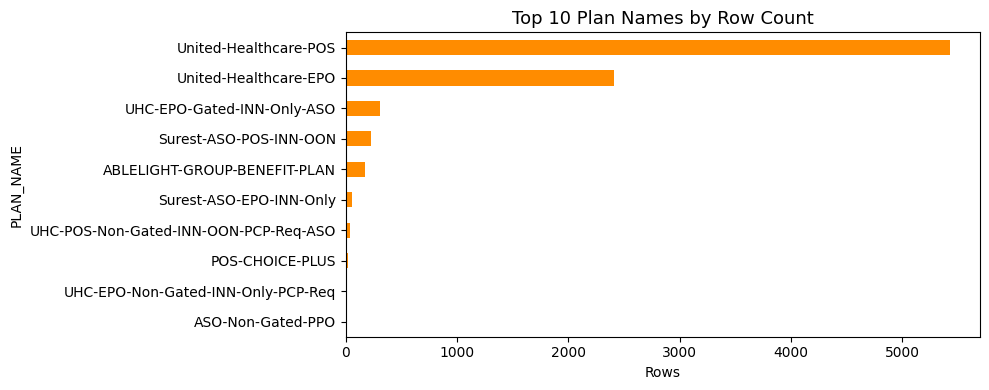

In [18]:
# --- Insight 1: Top 10 plan names ---
top_plans = df['PLAN_NAME'].value_counts().head(10)
print('Top 10 plan names:')
print(top_plans.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
top_plans.plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Top 10 Plan Names by Row Count', fontsize=13)
ax.set_xlabel('Rows')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
# --- Insight 2: In-network file description types ---
desc_counts = df['IN_NETWORK_DESCRIPTION'].value_counts(dropna=False)
print('In-network description types:')
print(desc_counts.to_string())

In-network description types:
IN_NETWORK_DESCRIPTION
in-network files                                 8711
in-network CMC Cancer shared files                 87
in-network CMC Transplant shared files             54
NaN                                                10
in-network MAPFRE shared file                       4
in-network CMC Kidney shared files                  1
in-network CMC Fertility Services shared file       1


Files with allowed_amount:    121 (12.1%)
Files without allowed_amount: 875 (87.9%)


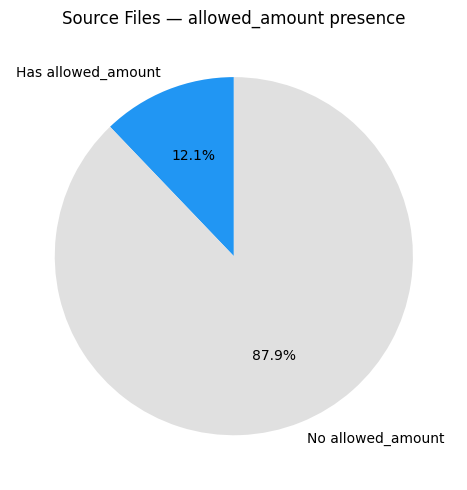

In [23]:
# --- Insight 3: Files with vs without allowed_amount ---
has_allowed = df.groupby('SOURCE_FILE')['ALLOWED_AMOUNT_LOCATION'].any()
counts = has_allowed.value_counts()
labels = ['Has allowed_amount', 'No allowed_amount']
values = [counts.get(True, 0), counts.get(False, 0)]

print(f'Files with allowed_amount:    {values[0]:>3} ({values[0]/sum(values)*100:.1f}%)')
print(f'Files without allowed_amount: {values[1]:>3} ({values[1]/sum(values)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(values, labels=labels, autopct='%1.1f%%', colors=['#2196F3', '#E0E0E0'], startangle=90)
ax.set_title('Source Files — allowed_amount presence', fontsize=12)
plt.tight_layout()
plt.show()

Avg in-network files per source:  8.9
Min:                              1
Max:                              174
Median:                           6.0


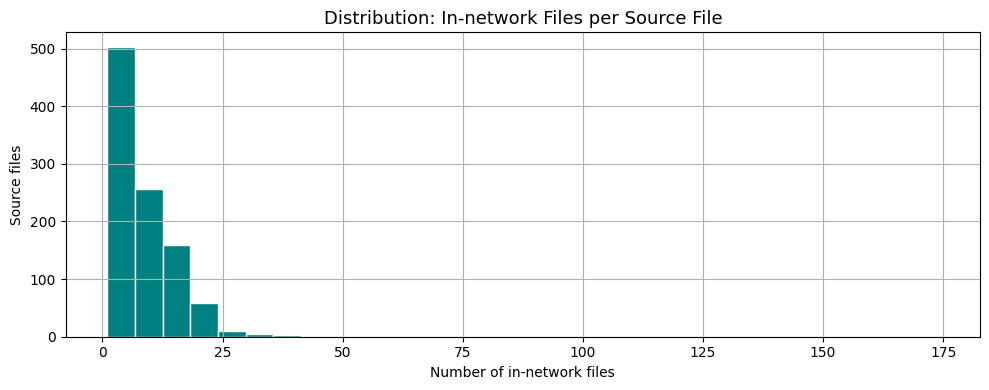

In [22]:
# --- Insight 4: In-network files per source file (distribution) ---
files_per_source = df.groupby('SOURCE_FILE').size()

print(f'Avg in-network files per source:  {files_per_source.mean():.1f}')
print(f'Min:                              {files_per_source.min()}')
print(f'Max:                              {files_per_source.max()}')
print(f'Median:                           {files_per_source.median()}')

fig, ax = plt.subplots(figsize=(10, 4))
files_per_source.hist(bins=30, ax=ax, color='teal', edgecolor='white')
ax.set_title('Distribution: In-network Files per Source File', fontsize=13)
ax.set_xlabel('Number of in-network files')
ax.set_ylabel('Source files')
plt.tight_layout()
plt.show()

In [24]:
# --- Insight 5: plan_sponsor_name nulls ---
null_sponsor = df[df['PLAN_SPONSOR_NAME'].isnull()]
print(f'Rows with null plan_sponsor_name: {len(null_sponsor)}')
print(f'Unique source files affected:     {null_sponsor["SOURCE_FILE"].nunique()}')
print('\nEntities with null sponsor:')
print(null_sponsor['REPORTING_ENTITY_NAME'].value_counts().to_string())

Rows with null plan_sponsor_name: 147
Unique source files affected:     22

Entities with null sponsor:
REPORTING_ENTITY_NAME
United-HealthCare-Services-Inc    117
UMR-Inc                            16
Oxford-Health-Plans-LLC            10
Surest                              3
United-HealthCare-Services          1


## 3. Summary

| Insight | Finding |
|---|---|
| Total rows | 8,868 across 996 source files |
| Reporting entities | 7 entities — United-HealthCare-Services-Inc dominates (88.4%) |
| Plan types | 100% group market — all employer-sponsored plans |
| Top plan | United-Healthcare-POS (5,428 rows, 61.2%) |
| In-network files | Avg 8.9 per source file — some files reference specialized networks (CMC Cancer, Transplant) |
| Allowed amounts | 121/996 files (12.1%) include allowed amount references |
| Data quality | 147 null plan_sponsor_name — explicit nulls in UHC source data |